Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
Columns after merge: ['Gap', 'addie', 'angelyn', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


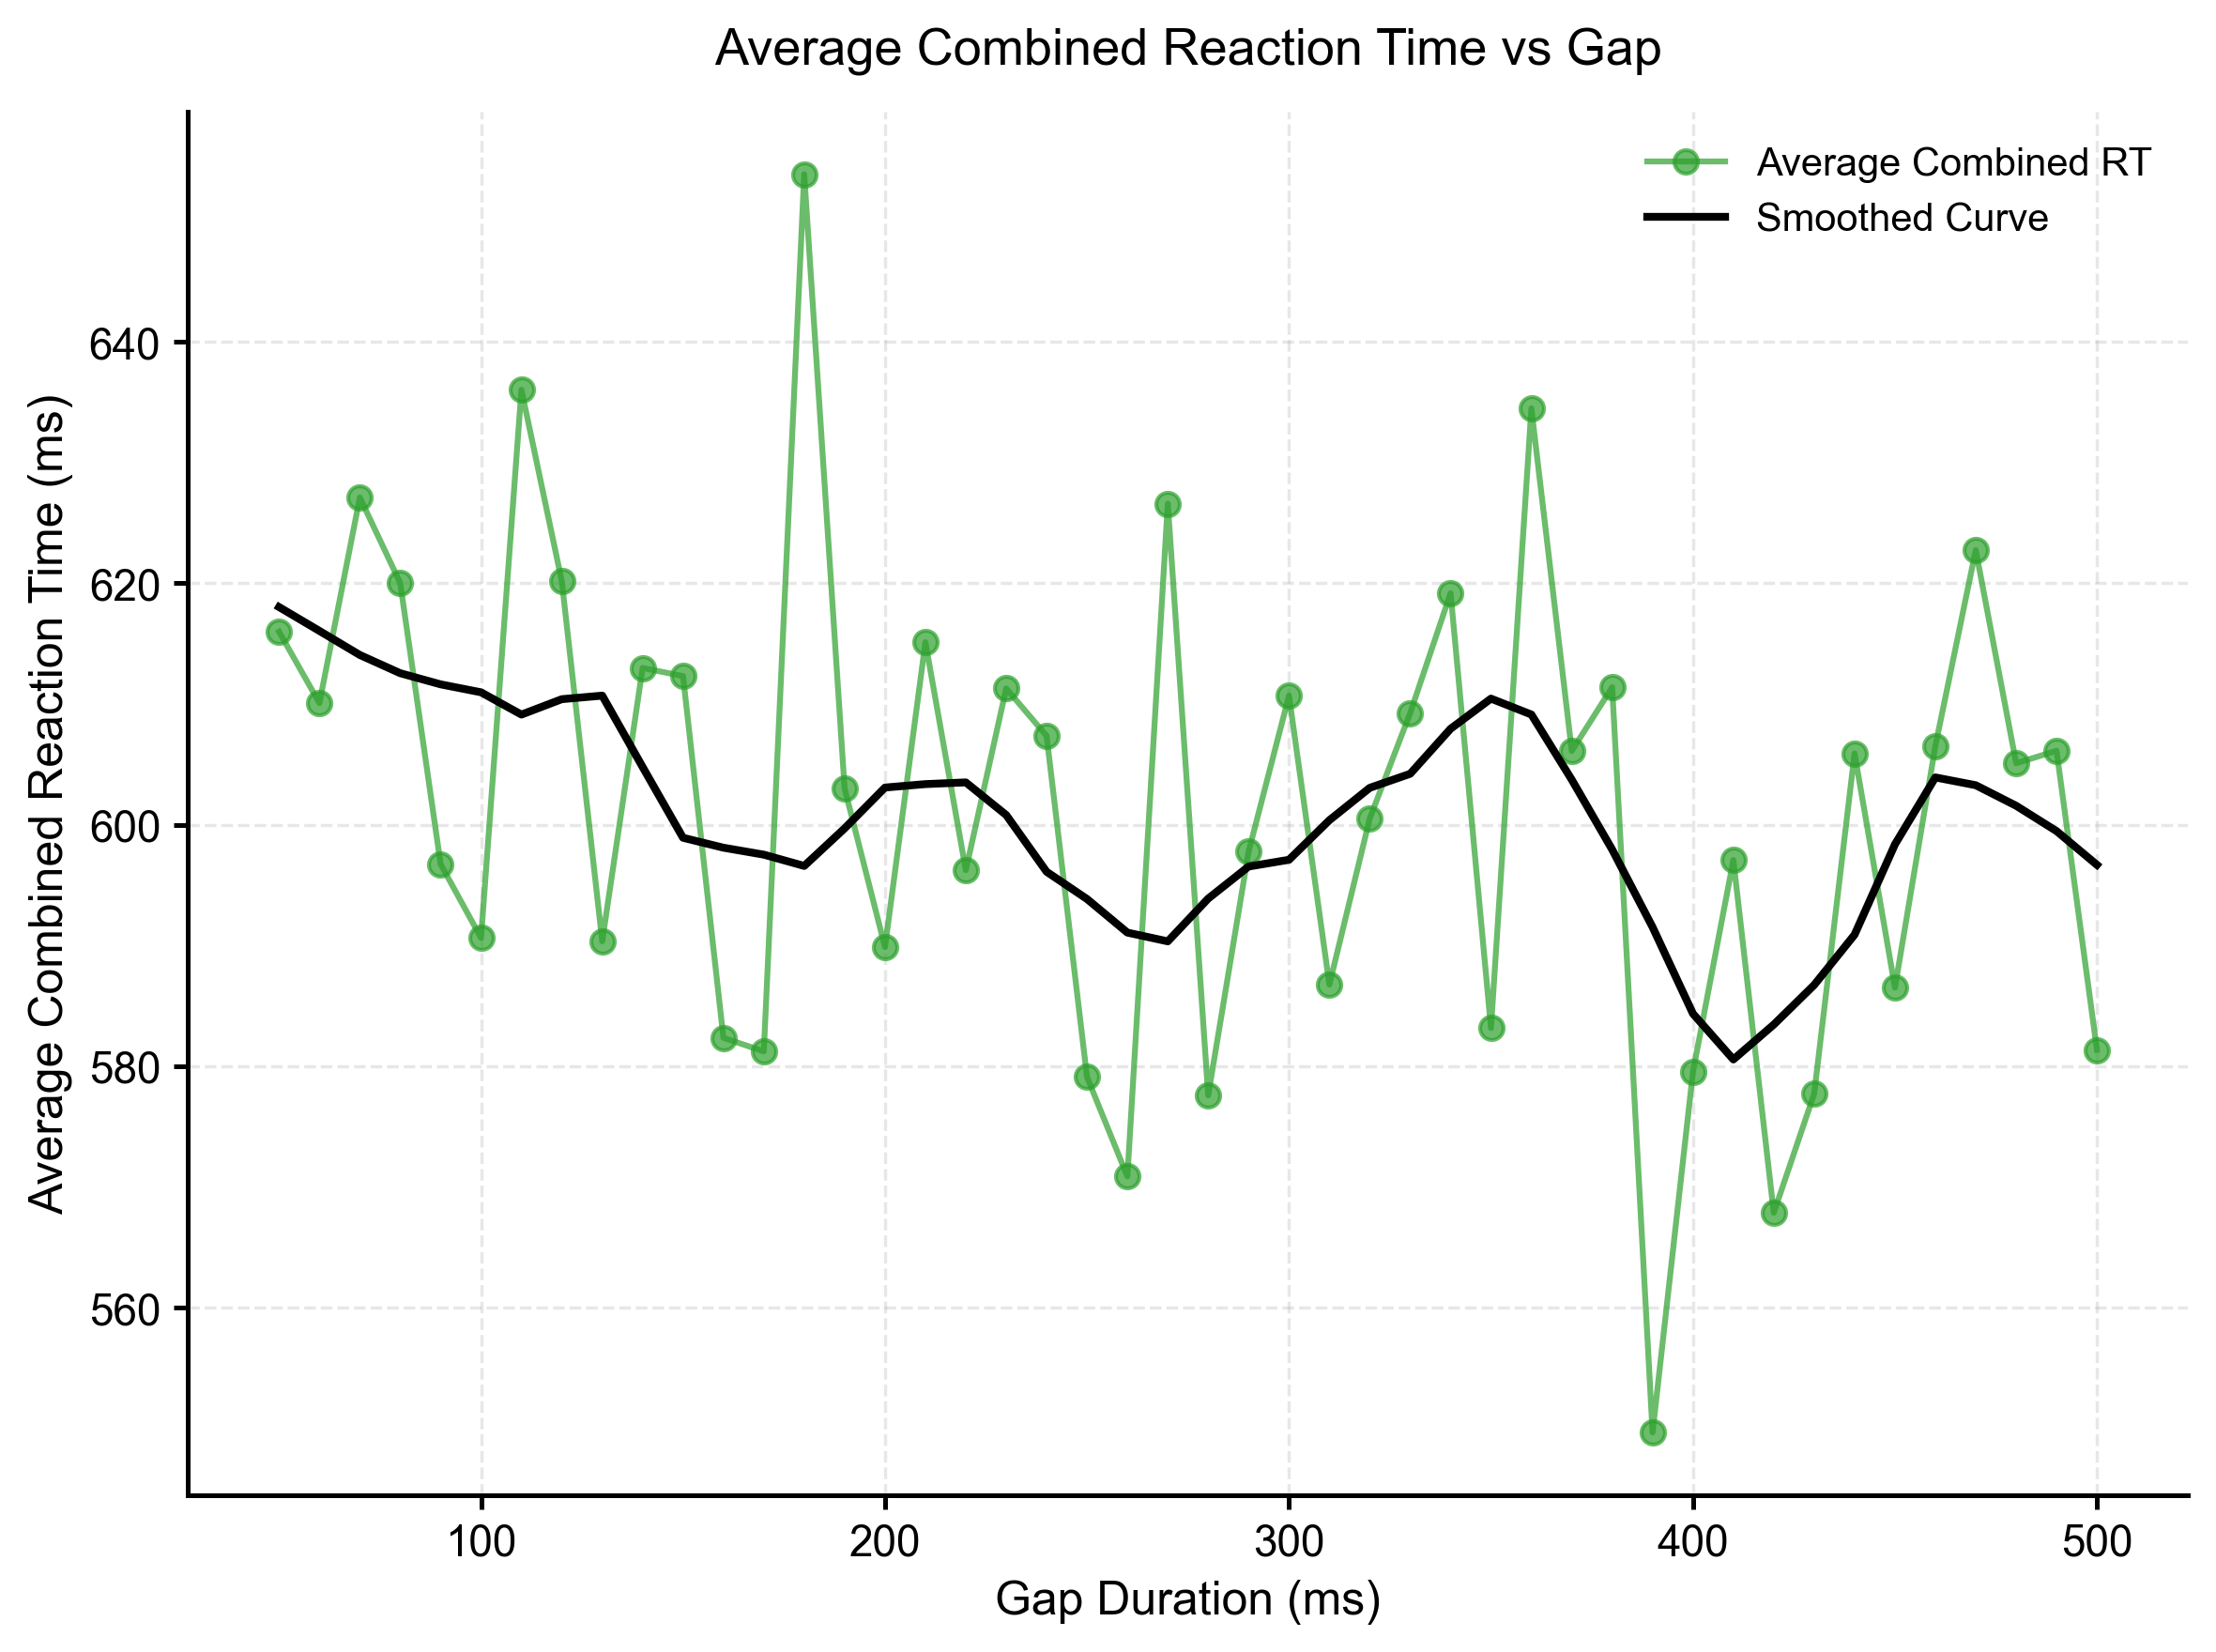


Saved plot to: graphs/avg_combined_rt_vs_gap.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- SMART PROJECT ROOT DETECTION ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break

base_path = project_root / "data" / "averaged"
print(f"Using base path: {base_path}")

# ---------------- PARTICIPANT DETECTION ---------------- #
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_combinedavg.csv"
    
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    
    # Detect column that contains CombinedAvgRT or CombinedAveRT
    rt_col = next((c for c in df.columns if 'Combined' in c and 'RT' in c), None)
    
    if 'Gap' not in df.columns or rt_col is None:
        continue

    df = df[['Gap', rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found. Check file paths and CSV structure.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df['AvgCombinedRT'] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTHING ---------------- #
smoothed = lowess(merged_df['AvgCombinedRT'], merged_df['Gap'], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(2)

ax.plot(merged_df['Gap'], merged_df['AvgCombinedRT'], 
        marker='o', color=color_avg, alpha=0.7, label='Average Combined RT')
ax.plot(smoothed[:, 0], smoothed[:, 1], 
        color='black', linewidth=2, label='Smoothed Curve')

ax.set_title('Average Combined Reaction Time vs Gap', pad=12)
ax.set_xlabel('Gap Duration (ms)')
ax.set_ylabel('Average Combined Reaction Time (ms)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save output
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_combined_rt_vs_gap.png"
plt.savefig(save_path, bbox_inches='tight', format='png')

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree', 'vidhya']
Columns after merge: ['Gap', 'addie', 'angelyn', 'jill', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree', 'vidhya']


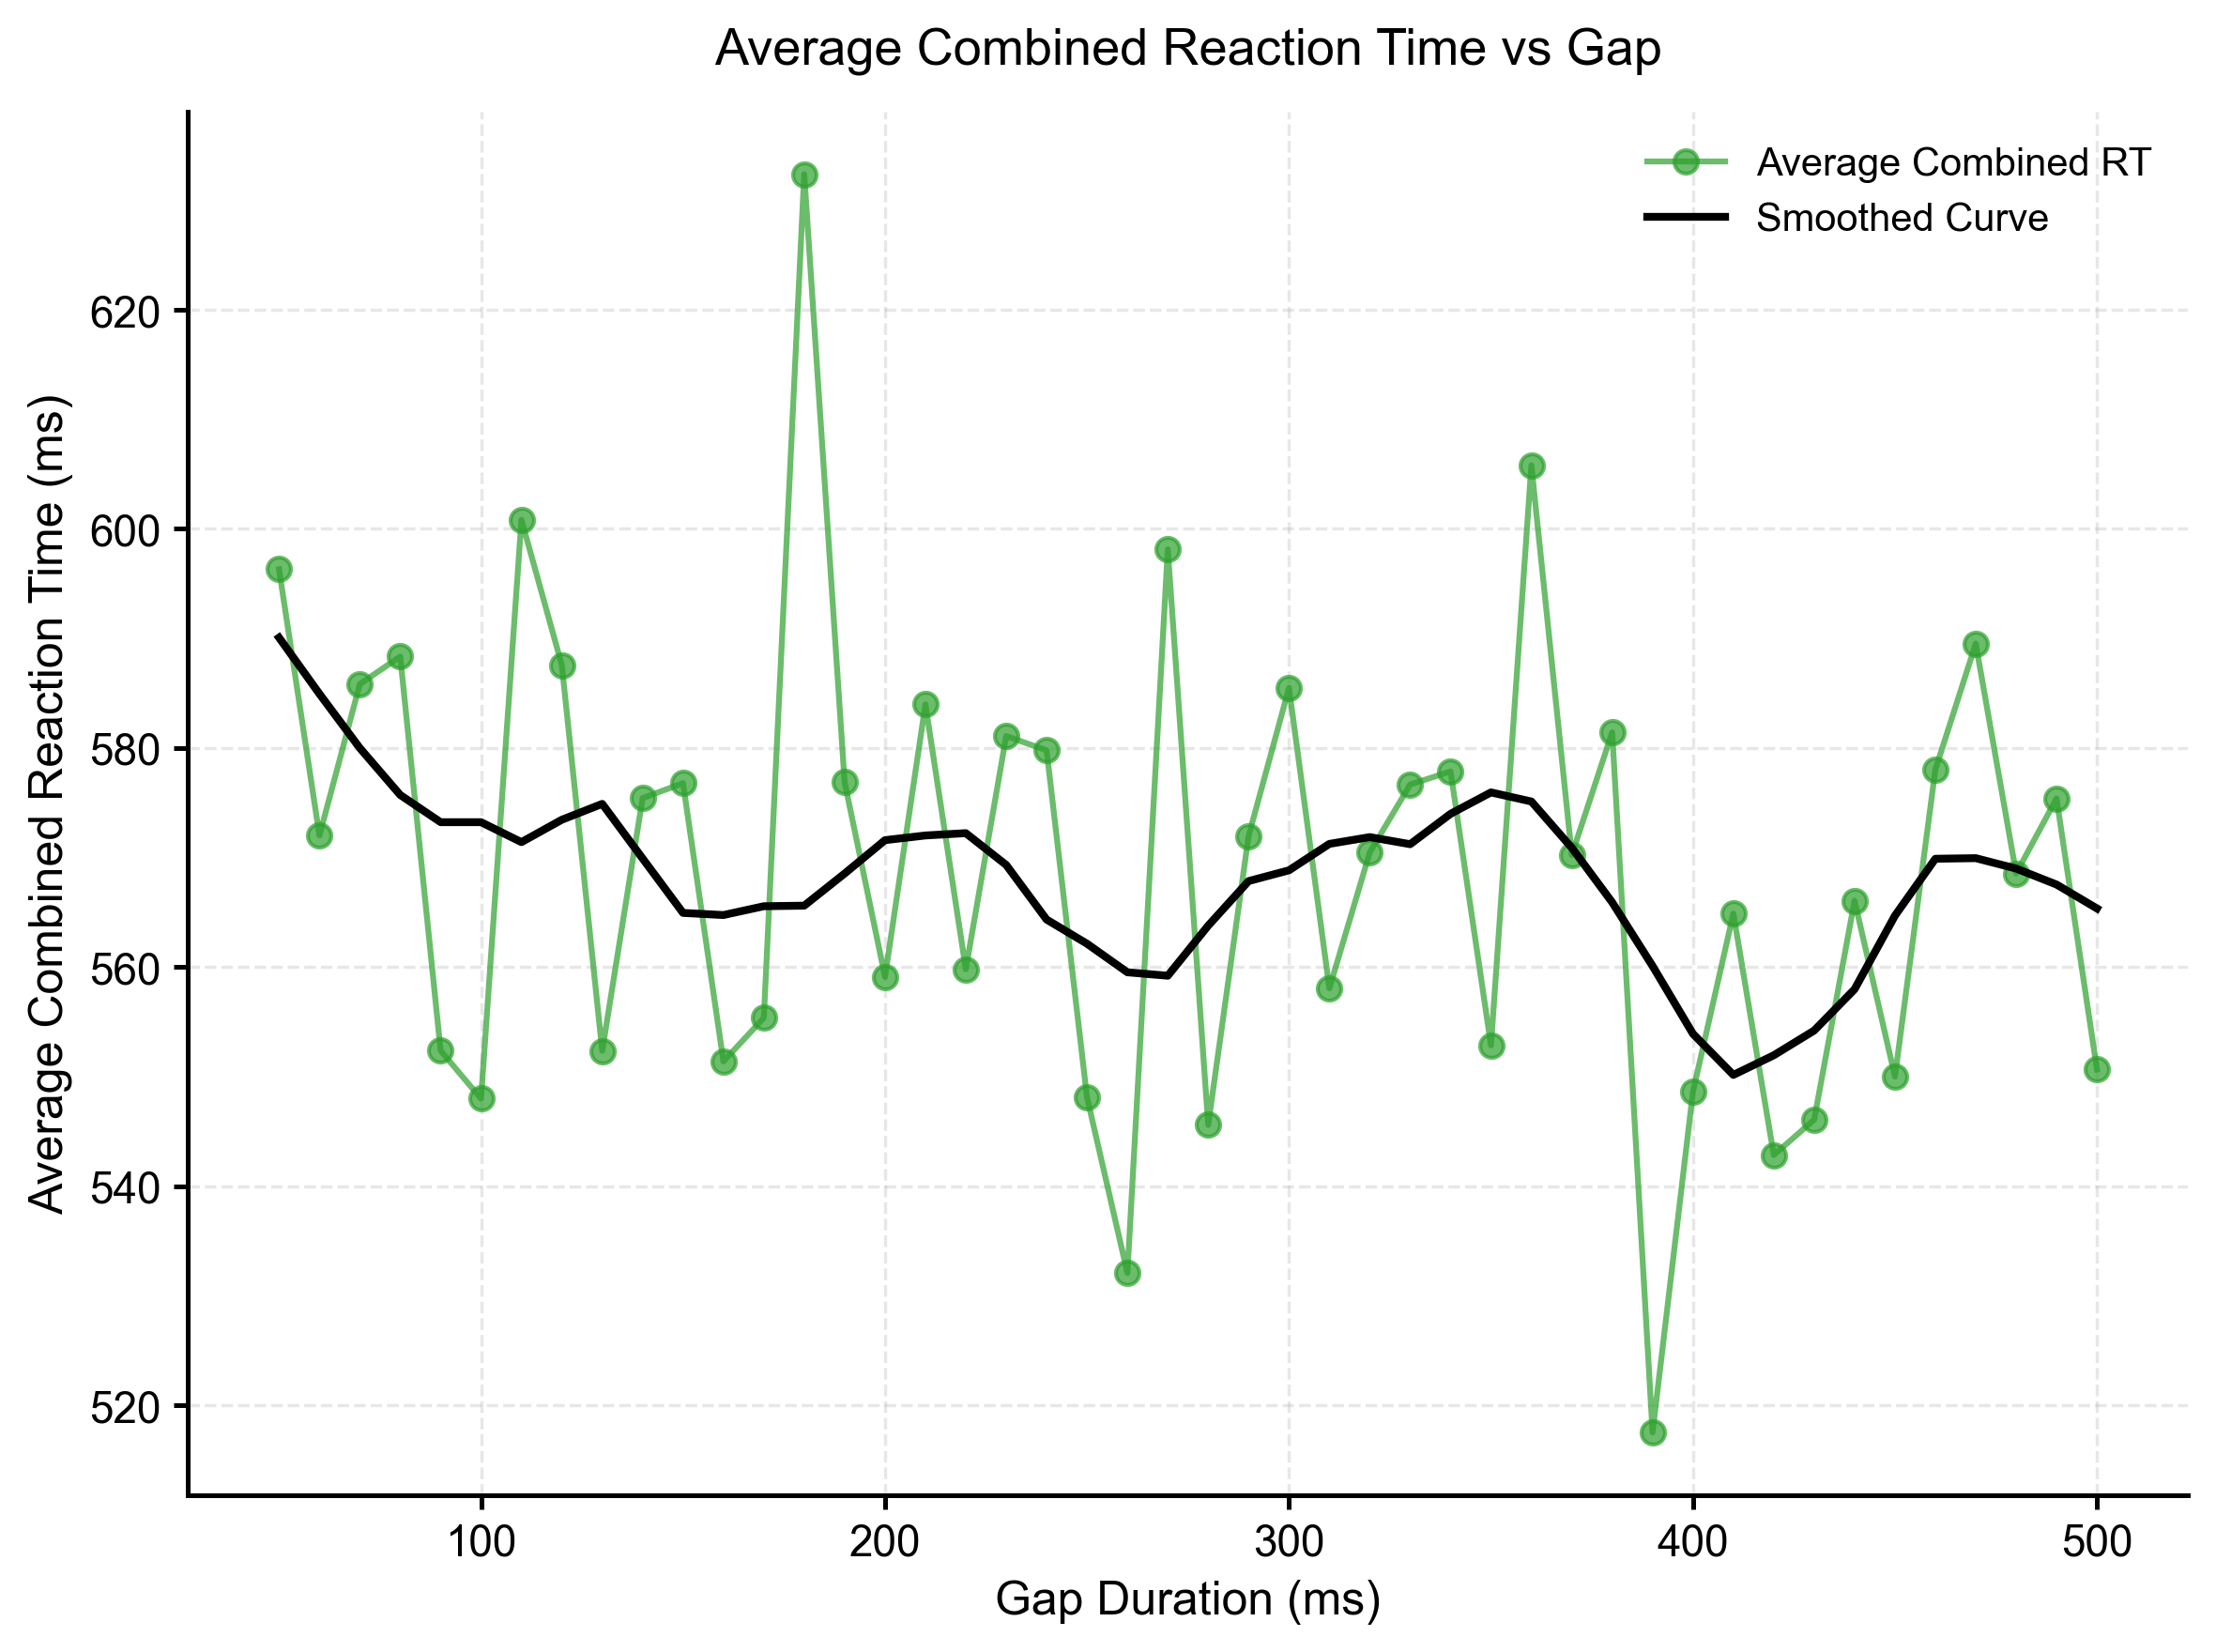


Saved plot to: graphs/avg_combined_rt_vs_gap.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- SMART PROJECT ROOT DETECTION ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break

base_path = project_root / "data" / "averaged"
print(f"Using base path: {base_path}")

# ---------------- PARTICIPANT DETECTION ---------------- #
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
participants.remove("manaswini")
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_combinedavg.csv"
    
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    
    rt_col = next((c for c in df.columns if 'Combined' in c and 'RT' in c), None)
    
    if 'Gap' not in df.columns or rt_col is None:
        continue

    df = df[['Gap', rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found. Check file paths and CSV structure.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df['AvgCombinedRT'] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTHING ---------------- #
smoothed = lowess(merged_df['AvgCombinedRT'], merged_df['Gap'], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(2)

ax.plot(merged_df['Gap'], merged_df['AvgCombinedRT'], 
        marker='o', color=color_avg, alpha=0.7, label='Average Combined RT')
ax.plot(smoothed[:, 0], smoothed[:, 1], 
        color='black', linewidth=2, label='Smoothed Curve')

ax.set_title('Average Combined Reaction Time vs Gap', pad=12)
ax.set_xlabel('Gap Duration (ms)')
ax.set_ylabel('Average Combined Reaction Time (ms)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save output
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_combined_rt_vs_gap.png"
plt.savefig(save_path, bbox_inches='tight', format='png')

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
No CSV found for all_combined, skipping...
No CSV found for combined, skipping...
Columns after merge: ['Gap', 'addie', 'angelyn', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


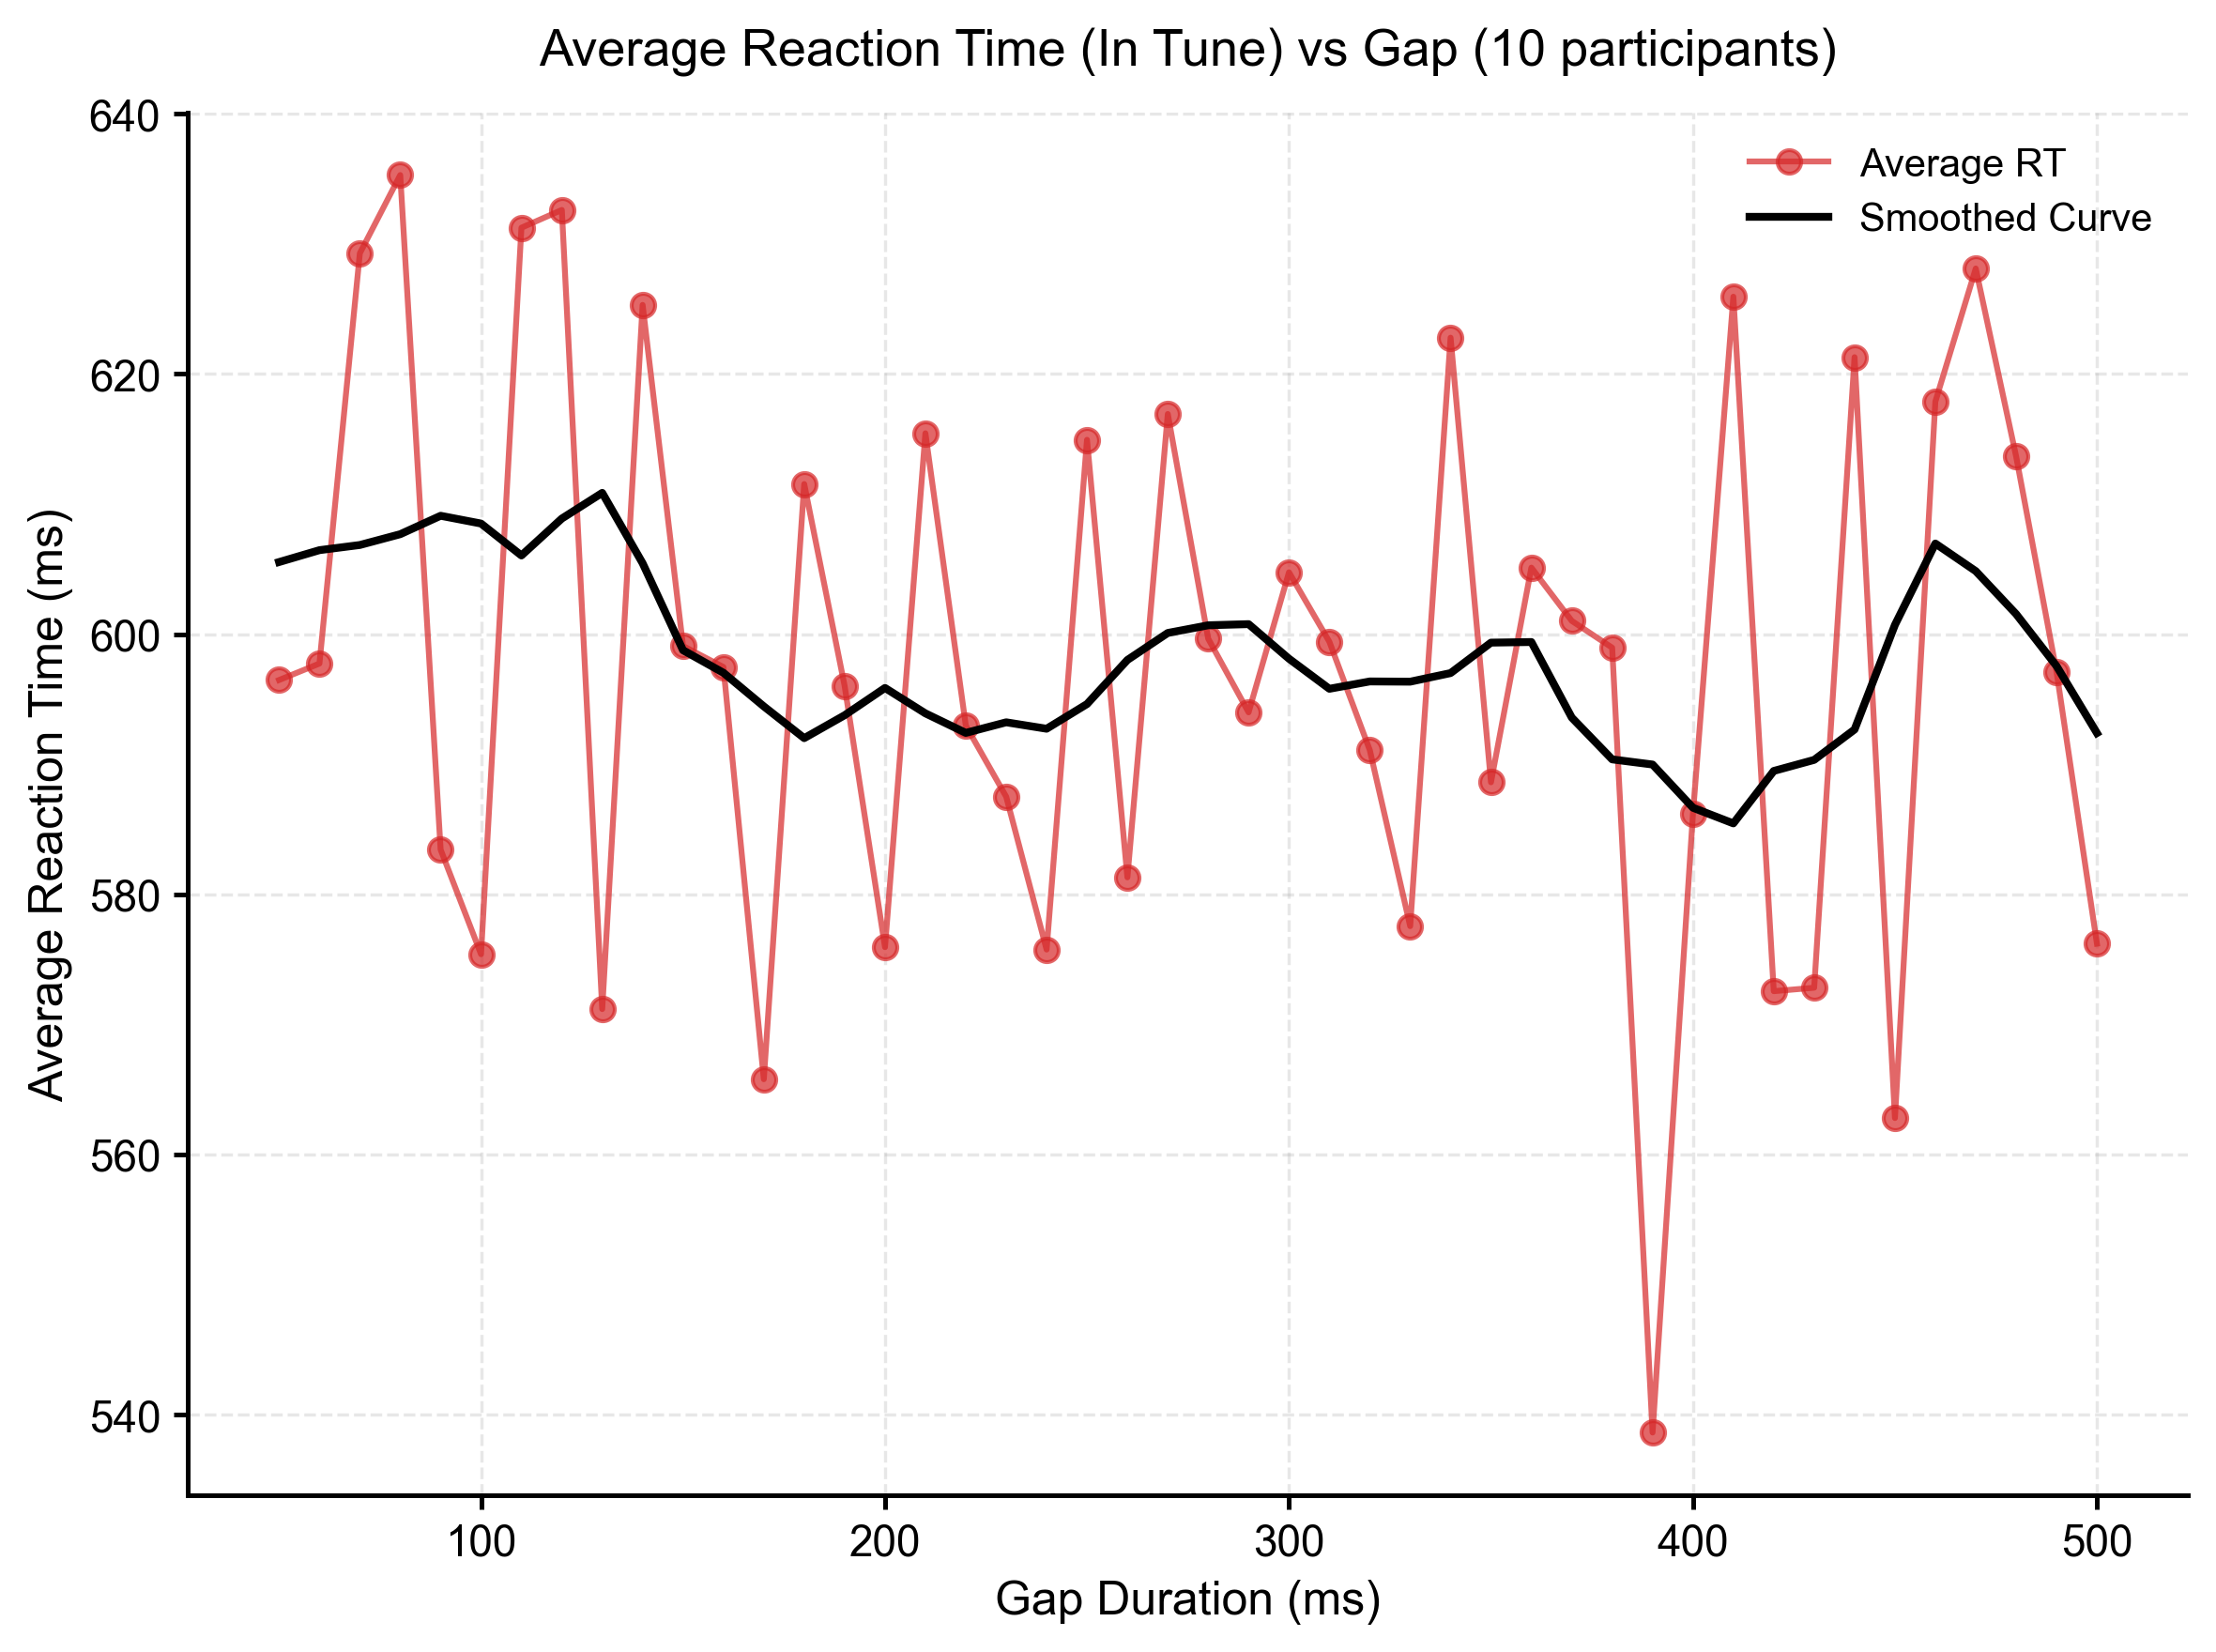


Saved plot to: graphs/avg_in_tune_reaction_time_vs_gap.png


In [9]:
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_inavg.csv"
    if not csv_path.exists():
        print(f"No CSV found for {participant}, skipping...")
        continue
    df = pd.read_csv(csv_path)

    # find column like addieInAveRT or angelynInAveRT
    rt_col = next((c for c in df.columns if "InAveRT" in c), None)
    if "Gap" not in df.columns or rt_col is None:
        print(f"Missing required columns in {participant}, skipping...")
        continue

    df = df[["Gap", rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on="Gap", how="inner")

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df["InAvgCombinedRT"] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTH ---------------- #
smoothed = lowess(merged_df["InAvgCombinedRT"], merged_df["Gap"], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(3)

ax.plot(merged_df["Gap"], merged_df["InAvgCombinedRT"], marker="o", color=color_avg, alpha=0.7, label="Average RT")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2, label="Smoothed Curve")

ax.set_title(f"Average Reaction Time (In Tune) vs Gap ({len(valid_participants)} participants)", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Average Reaction Time (ms)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_in_tune_reaction_time_vs_gap.png"
plt.savefig(save_path, bbox_inches="tight", format="png")

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
No CSV found for all_combined, skipping...
No CSV found for combined, skipping...
Columns after merge: ['Gap', 'addie', 'angelyn', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


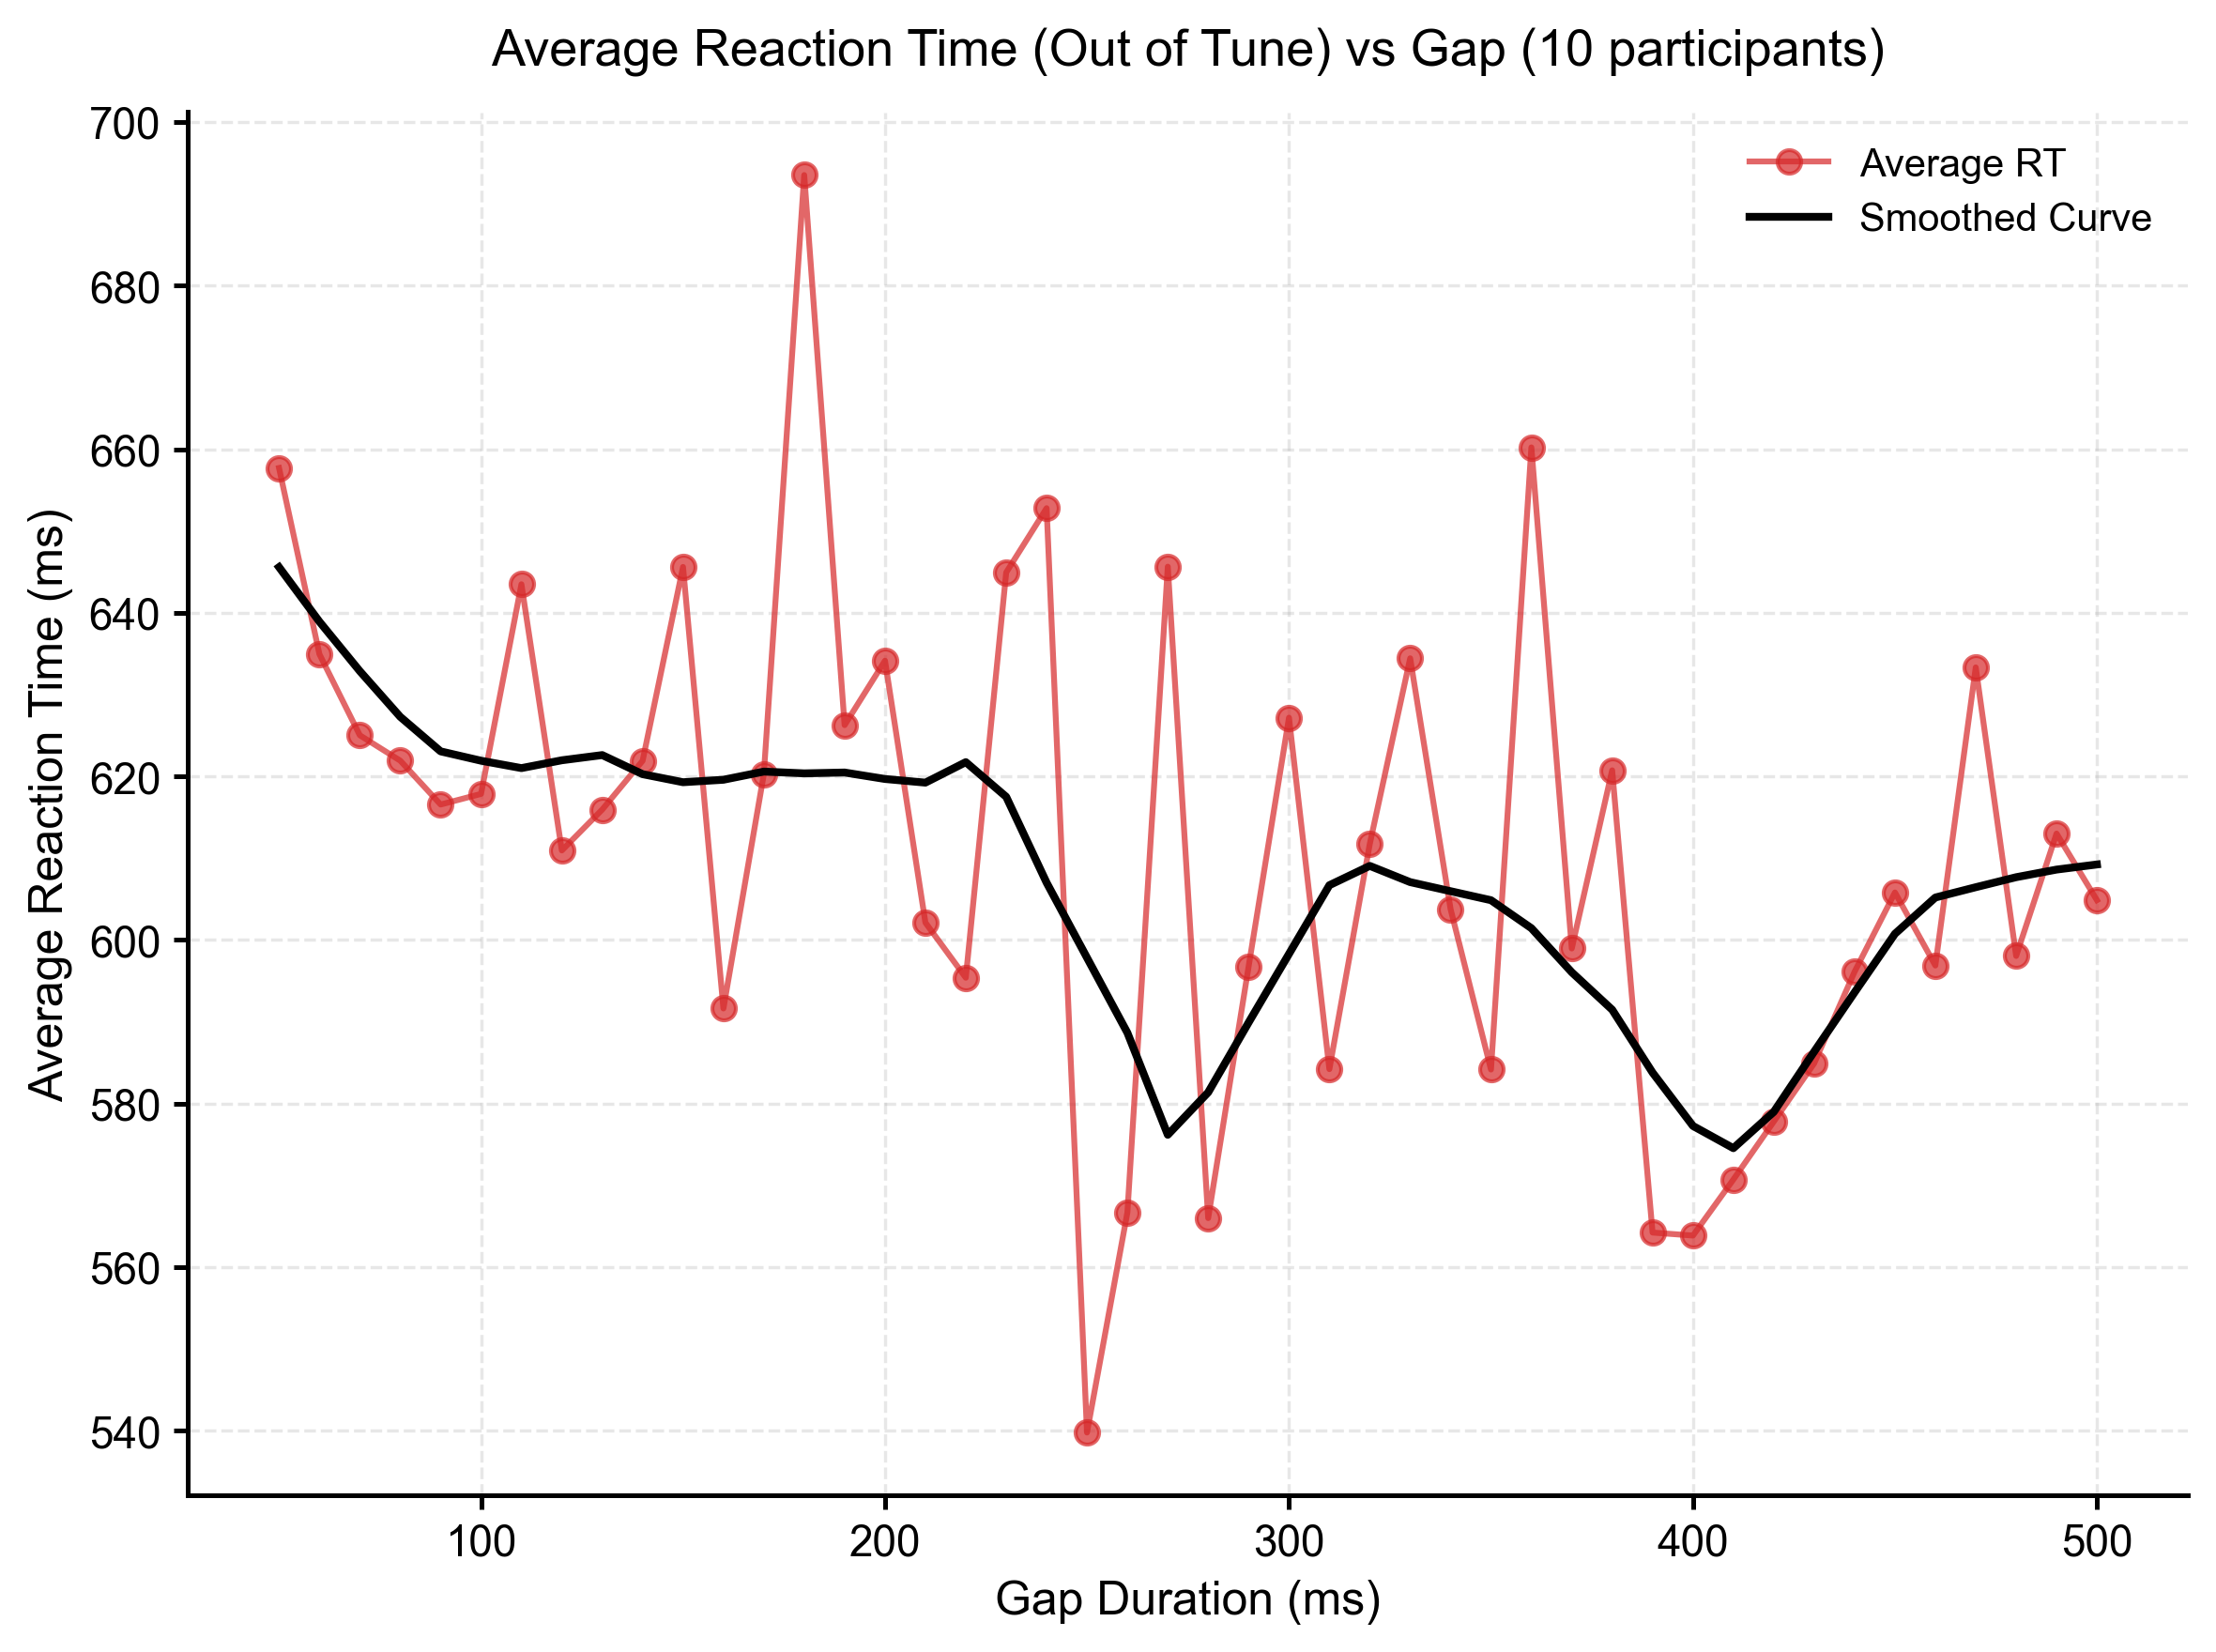


Saved plot to: graphs/avg_out_of_tune_reaction_time_vs_gap.png


In [10]:
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_outavg.csv"
    if not csv_path.exists():
        print(f"No CSV found for {participant}, skipping...")
        continue
    df = pd.read_csv(csv_path)

    # find column like addieInAveRT or angelynInAveRT
    rt_col = next((c for c in df.columns if "OutAveRT" in c), None)
    if "Gap" not in df.columns or rt_col is None:
        print(f"Missing required columns in {participant}, skipping...")
        continue

    df = df[["Gap", rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on="Gap", how="inner")

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df["OutAvgCombinedRT"] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTH ---------------- #
smoothed = lowess(merged_df["OutAvgCombinedRT"], merged_df["Gap"], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(3)

ax.plot(merged_df["Gap"], merged_df["OutAvgCombinedRT"], marker="o", color=color_avg, alpha=0.7, label="Average RT")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2, label="Smoothed Curve")

ax.set_title(f"Average Reaction Time (Out of Tune) vs Gap ({len(valid_participants)} participants)", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Average Reaction Time (ms)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_out_of_tune_reaction_time_vs_gap.png"
plt.savefig(save_path, bbox_inches="tight", format="png")

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


📂 Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
Missing data for all_combined, skipping...
Missing data for combined, skipping...
Averaged 10 in-tune participants and 10 out-of-tune participants.


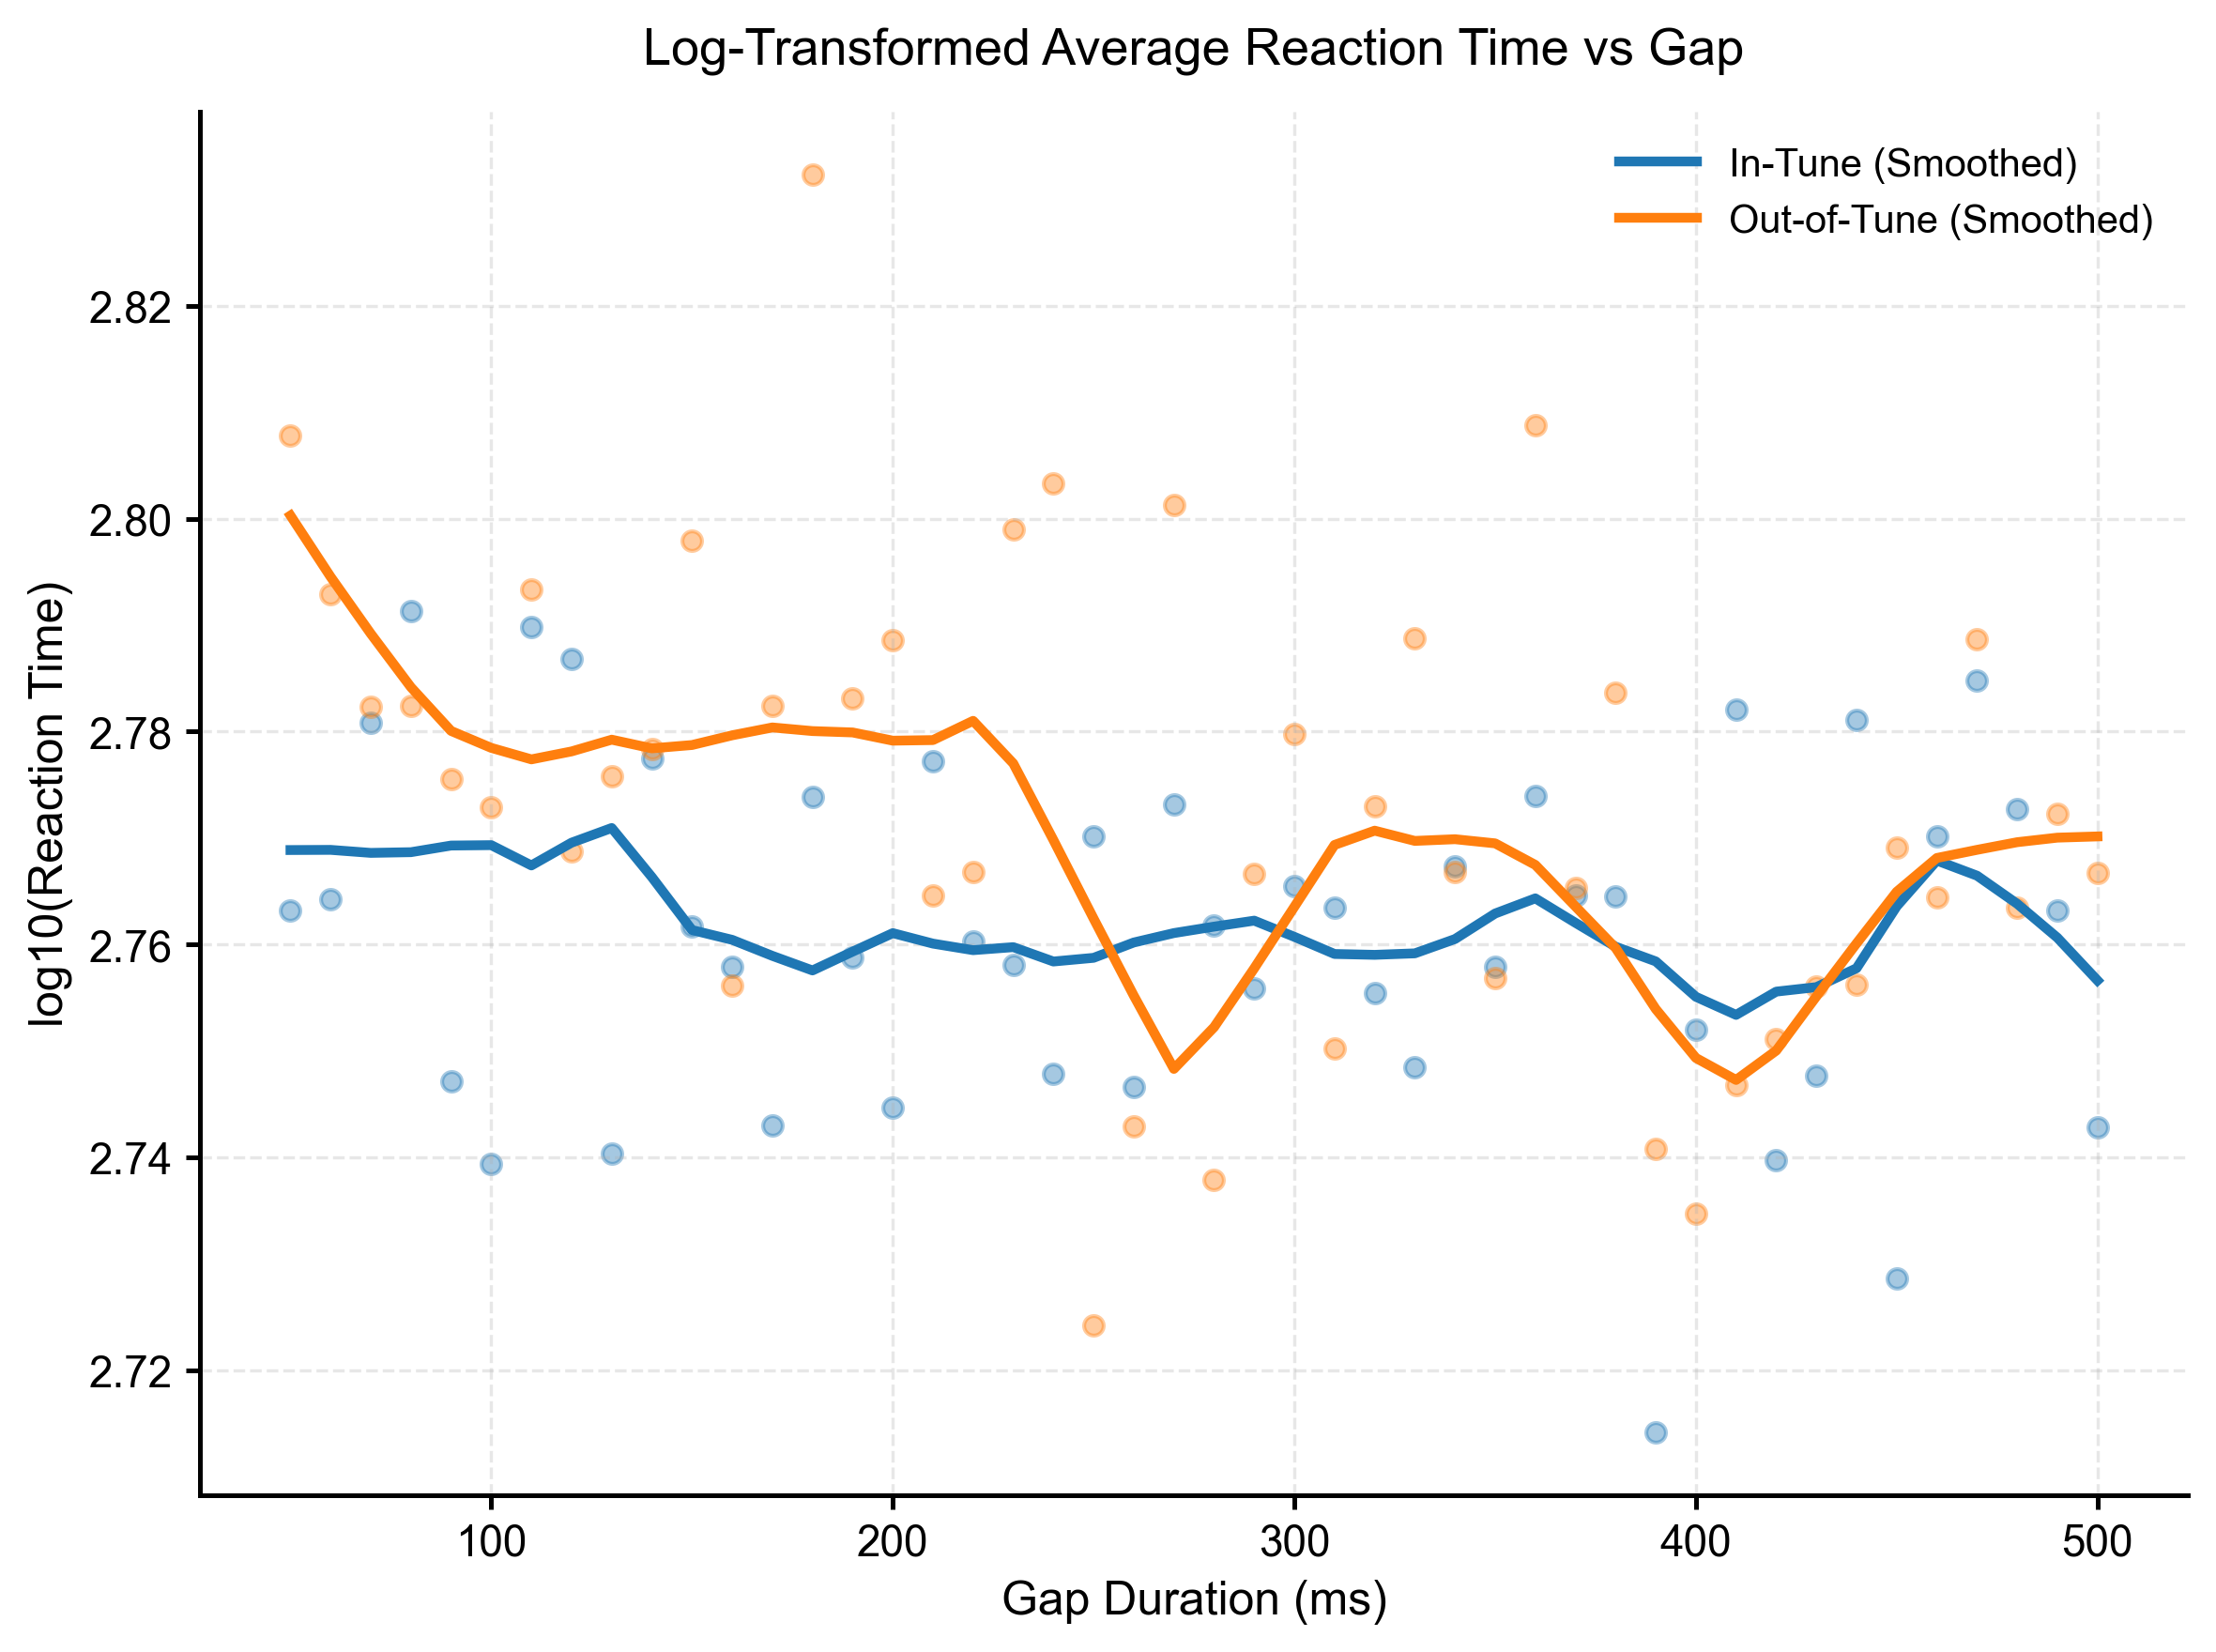


Saved plot to: plots/avg_log_rt_in_out_smooth.png


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- FIND PROJECT ROOT ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break
else:
    raise FileNotFoundError("❌ Could not find 'Temporal-Attention' directory in path hierarchy.")

base_path = project_root / "data" / "averaged"
print(f"📂 Using base path: {base_path}")

# ---------------- DETECT PARTICIPANTS ---------------- #
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

# ---------------- LOAD DATA ---------------- #
in_dfs, out_dfs = [], []

for participant in participants:
    in_path = base_path / participant / f"{participant}_inavg.csv"
    out_path = base_path / participant / f"{participant}_outavg.csv"

    if not in_path.exists() or not out_path.exists():
        print(f"Missing data for {participant}, skipping...")
        continue

    in_df = pd.read_csv(in_path)
    out_df = pd.read_csv(out_path)

    # find column names
    in_col = next((c for c in in_df.columns if "InAveRT" in c), None)
    out_col = next((c for c in out_df.columns if "OutAveRT" in c), None)

    if "Gap" not in in_df.columns or in_col is None or "Gap" not in out_df.columns or out_col is None:
        print(f"Invalid columns for {participant}, skipping...")
        continue

    in_df = in_df[["Gap", in_col]].rename(columns={in_col: participant})
    out_df = out_df[["Gap", out_col]].rename(columns={out_col: participant})

    # log-transform reaction times
    in_df[participant] = np.log10(in_df[participant])
    out_df[participant] = np.log10(out_df[participant])

    in_dfs.append(in_df)
    out_dfs.append(out_df)

# ---------------- MERGE & AVERAGE ---------------- #
def merge_and_average(dfs):
    merged = dfs[0]
    for df in dfs[1:]:
        merged = pd.merge(merged, df, on="Gap", how="inner")
    subjects = [c for c in merged.columns if c != "Gap"]
    merged["MeanLogRT"] = merged[subjects].mean(axis=1)
    return merged, subjects

merged_in, subjects_in = merge_and_average(in_dfs)
merged_out, subjects_out = merge_and_average(out_dfs)

print(f"Averaged {len(subjects_in)} in-tune participants and {len(subjects_out)} out-of-tune participants.")

# ---------------- SMOOTH ---------------- #
frac = 0.2
smoothed_in = lowess(merged_in["MeanLogRT"], merged_in["Gap"], frac=frac)
smoothed_out = lowess(merged_out["MeanLogRT"], merged_out["Gap"], frac=frac)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_in = plt.get_cmap("tab10")(0)
color_out = plt.get_cmap("tab10")(1)

ax.plot(smoothed_in[:, 0], smoothed_in[:, 1], color=color_in, linewidth=2.5, label="In-Tune (Smoothed)")
ax.plot(smoothed_out[:, 0], smoothed_out[:, 1], color=color_out, linewidth=2.5, label="Out-of-Tune (Smoothed)")
ax.scatter(merged_in["Gap"], merged_in["MeanLogRT"], color=color_in, alpha=0.4, s=25)
ax.scatter(merged_out["Gap"], merged_out["MeanLogRT"], color=color_out, alpha=0.4, s=25)

ax.set_title("Log-Transformed Average Reaction Time vs Gap", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("log10(Reaction Time)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_log_rt_in_out_smooth.png"
plt.savefig(save_path, bbox_inches="tight", format="png")
plt.show()

print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


📂 Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
⚠️ Missing data for all_combined, skipping...
⚠️ Missing data for combined, skipping...
✅ Loaded 10 in-tune and 10 out-of-tune datasets.
✅ Smoothed and averaged 10 in-tune and 10 out-of-tune participants.


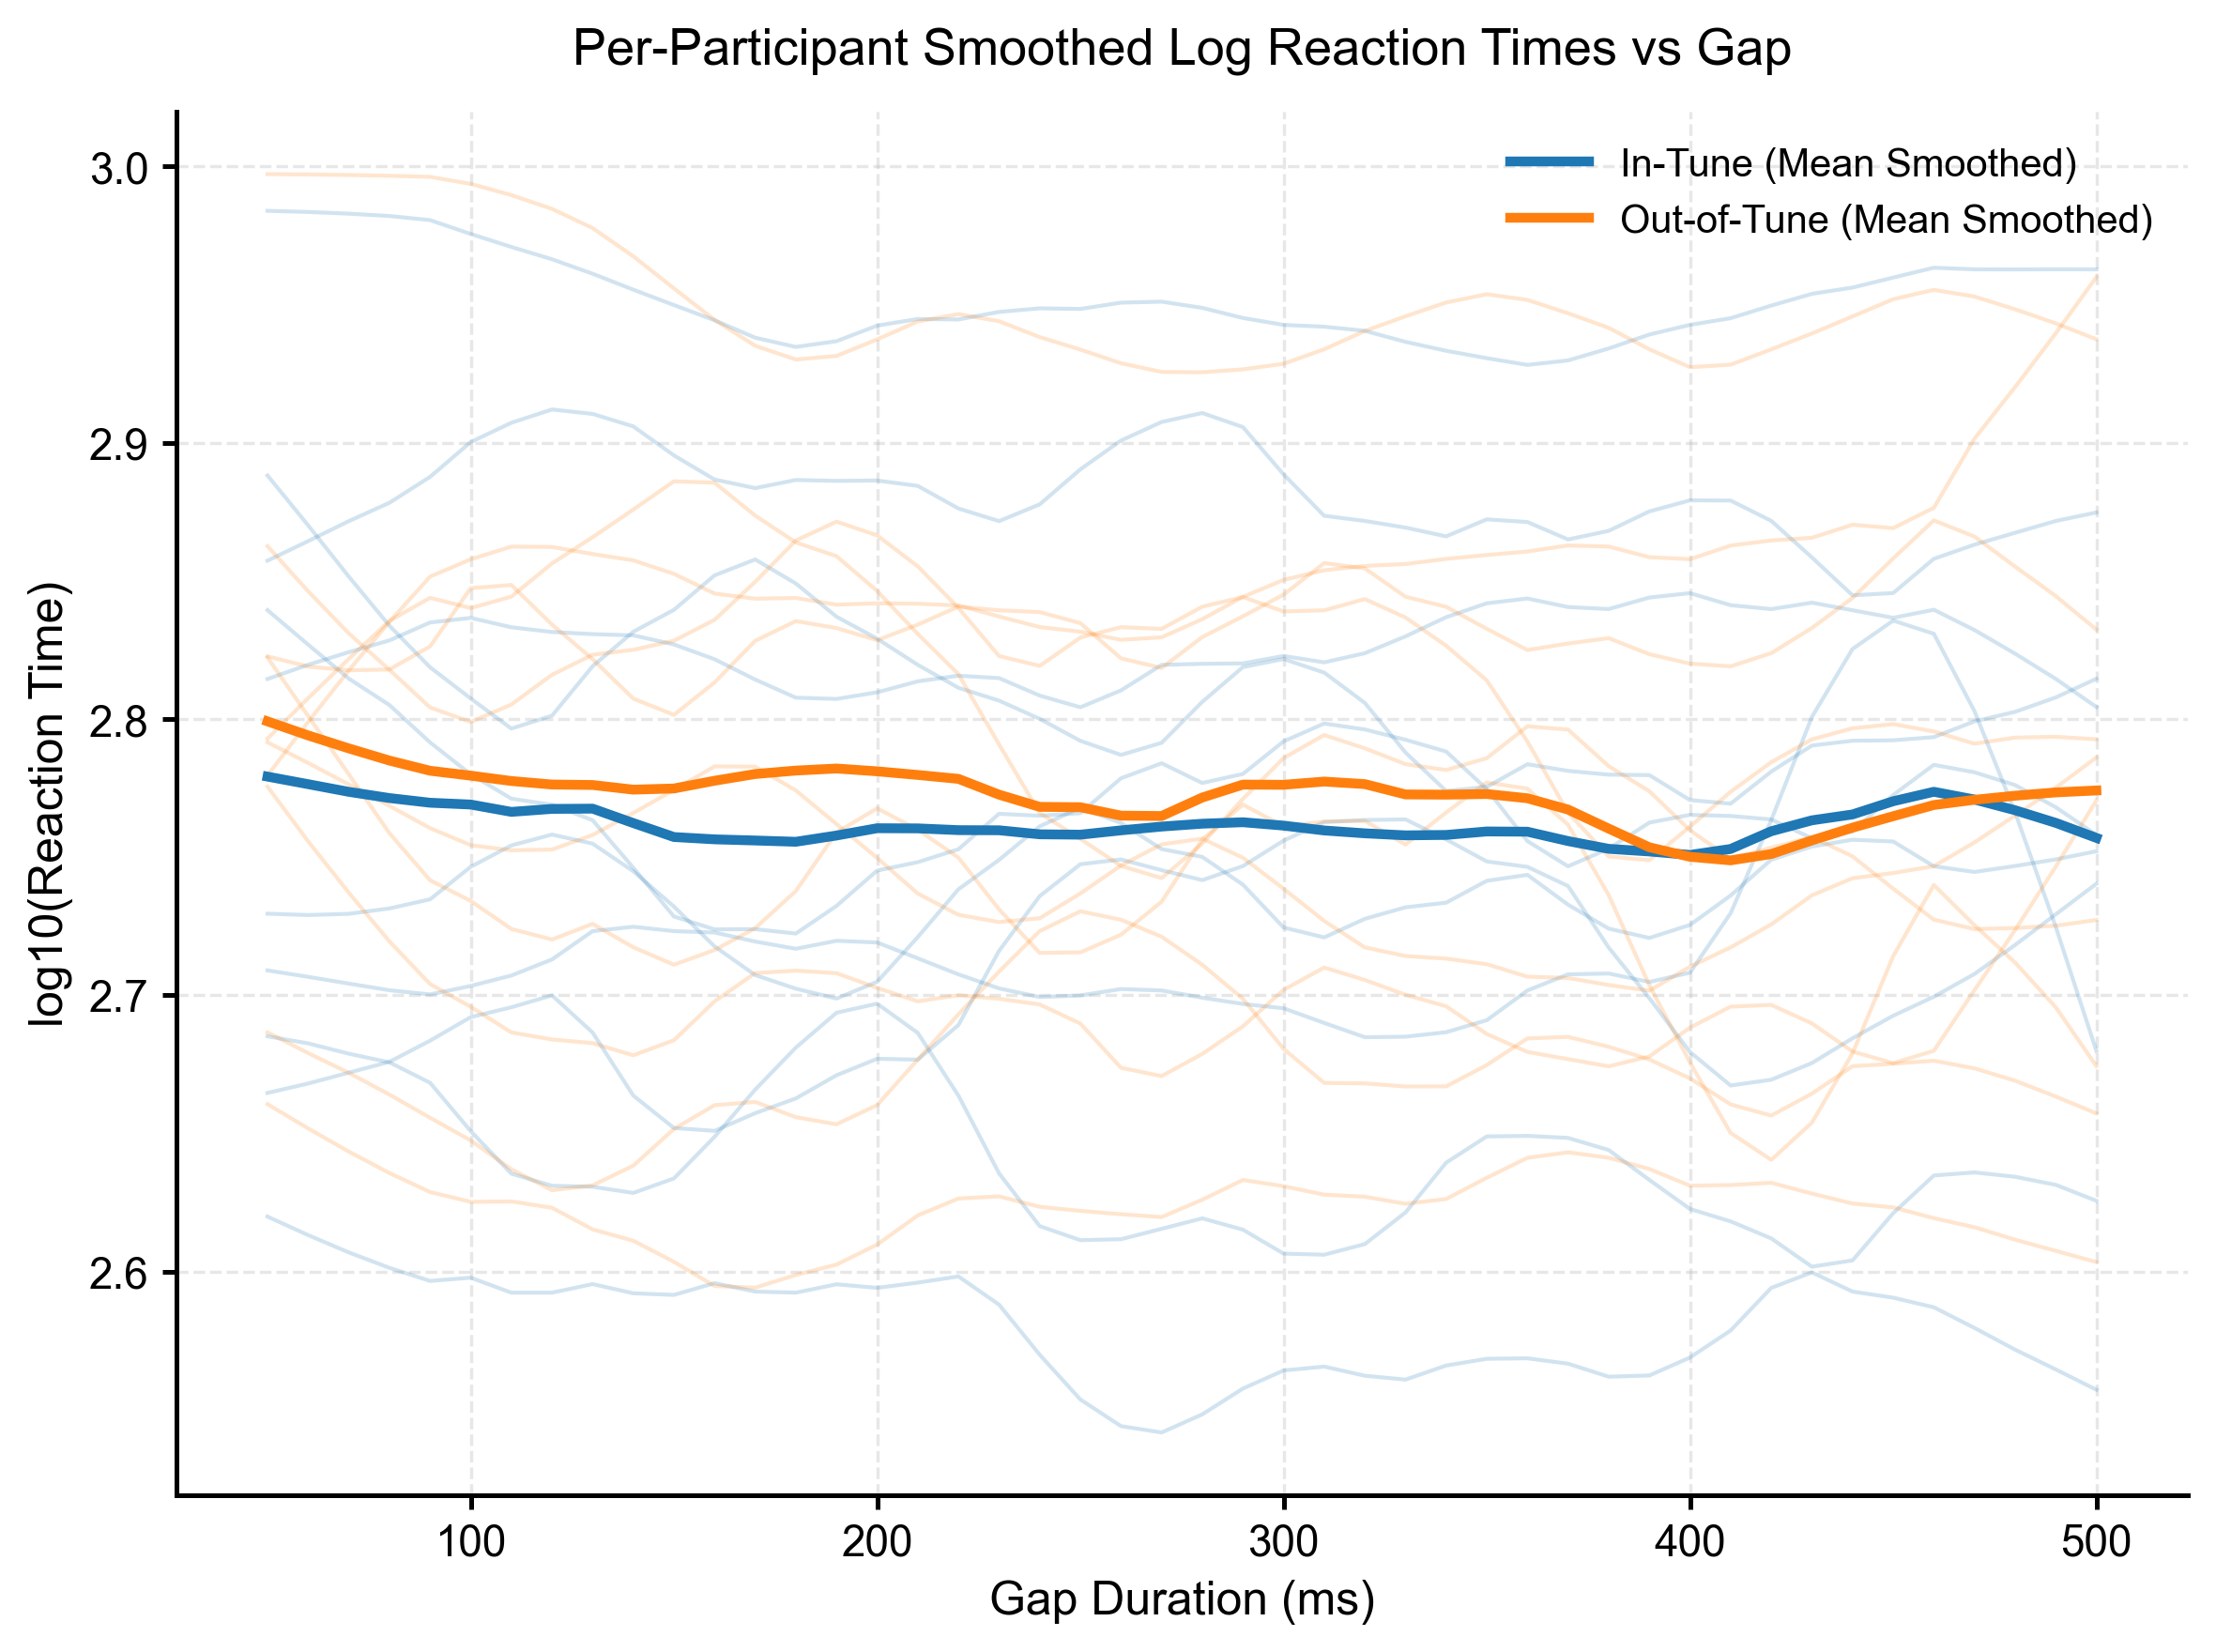


✅ Saved participant-smoothed plot to: plots/avg_log_rt_in_out_smooth_first.png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- FIND PROJECT ROOT ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break
else:
    raise FileNotFoundError("❌ Could not find 'Temporal-Attention' directory in path hierarchy.")

base_path = project_root / "data" / "averaged"
print(f"📂 Using base path: {base_path}")

# ---------------- DETECT PARTICIPANTS ---------------- #
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

# ---------------- LOAD DATA ---------------- #
in_dfs, out_dfs = [], []

for participant in participants:
    in_path = base_path / participant / f"{participant}_inavg.csv"
    out_path = base_path / participant / f"{participant}_outavg.csv"

    if not in_path.exists() or not out_path.exists():
        print(f"⚠️ Missing data for {participant}, skipping...")
        continue

    in_df = pd.read_csv(in_path)
    out_df = pd.read_csv(out_path)

    # find column names
    in_col = next((c for c in in_df.columns if "InAveRT" in c), None)
    out_col = next((c for c in out_df.columns if "OutAveRT" in c), None)

    if "Gap" not in in_df.columns or in_col is None or "Gap" not in out_df.columns or out_col is None:
        print(f"⚠️ Invalid columns for {participant}, skipping...")
        continue

    # Select and rename
    in_df = in_df[["Gap", in_col]].rename(columns={in_col: participant})
    out_df = out_df[["Gap", out_col]].rename(columns={out_col: participant})

    # log-transform reaction times
    in_df[participant] = np.log10(in_df[participant])
    out_df[participant] = np.log10(out_df[participant])

    in_dfs.append(in_df)
    out_dfs.append(out_df)

print(f"✅ Loaded {len(in_dfs)} in-tune and {len(out_dfs)} out-of-tune datasets.")

# ---------------- SMOOTH EACH PARTICIPANT BEFORE AVERAGING ---------------- #
def smooth_each_then_average(dfs, frac=0.2):
    """Smooth each participant individually, interpolate to common x-axis, and average."""
    all_gaps = sorted(set(np.concatenate([df['Gap'].values for df in dfs])))
    smoothed_curves = []

    for df in dfs:
        subj = [c for c in df.columns if c != 'Gap'][0]
        smoothed = lowess(df[subj], df['Gap'], frac=frac)
        smoothed_interp = np.interp(all_gaps, smoothed[:, 0], smoothed[:, 1])
        smoothed_curves.append(smoothed_interp)

    smoothed_curves = np.vstack(smoothed_curves)
    mean_smoothed = np.mean(smoothed_curves, axis=0)
    return pd.DataFrame({'Gap': all_gaps, 'MeanSmoothedLogRT': mean_smoothed}), smoothed_curves

smoothed_in_df, smoothed_in_curves = smooth_each_then_average(in_dfs, frac=0.2)
smoothed_out_df, smoothed_out_curves = smooth_each_then_average(out_dfs, frac=0.2)

print(f"✅ Smoothed and averaged {smoothed_in_curves.shape[0]} in-tune and {smoothed_out_curves.shape[0]} out-of-tune participants.")

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_in = plt.get_cmap("tab10")(0)
color_out = plt.get_cmap("tab10")(1)

# Plot faint individual curves
for curve in smoothed_in_curves:
    ax.plot(smoothed_in_df['Gap'], curve, color=color_in, alpha=0.2, linewidth=1)
for curve in smoothed_out_curves:
    ax.plot(smoothed_out_df['Gap'], curve, color=color_out, alpha=0.2, linewidth=1)

# Plot mean smoothed lines
ax.plot(smoothed_in_df['Gap'], smoothed_in_df['MeanSmoothedLogRT'],
        color=color_in, linewidth=2.5, label='In-Tune (Mean Smoothed)')
ax.plot(smoothed_out_df['Gap'], smoothed_out_df['MeanSmoothedLogRT'],
        color=color_out, linewidth=2.5, label='Out-of-Tune (Mean Smoothed)')

ax.set_title("Per-Participant Smoothed Log Reaction Times vs Gap", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("log10(Reaction Time)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_log_rt_in_out_smooth_first.png"
plt.savefig(save_path, bbox_inches="tight", format="png")
plt.show()

print(f"\n✅ Saved participant-smoothed plot to: {save_path.relative_to(project_root)}")


📂 Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
⚠️ Missing data for all_combined, skipping...
⚠️ Missing data for combined, skipping...
✅ Loaded data for 10 participants.


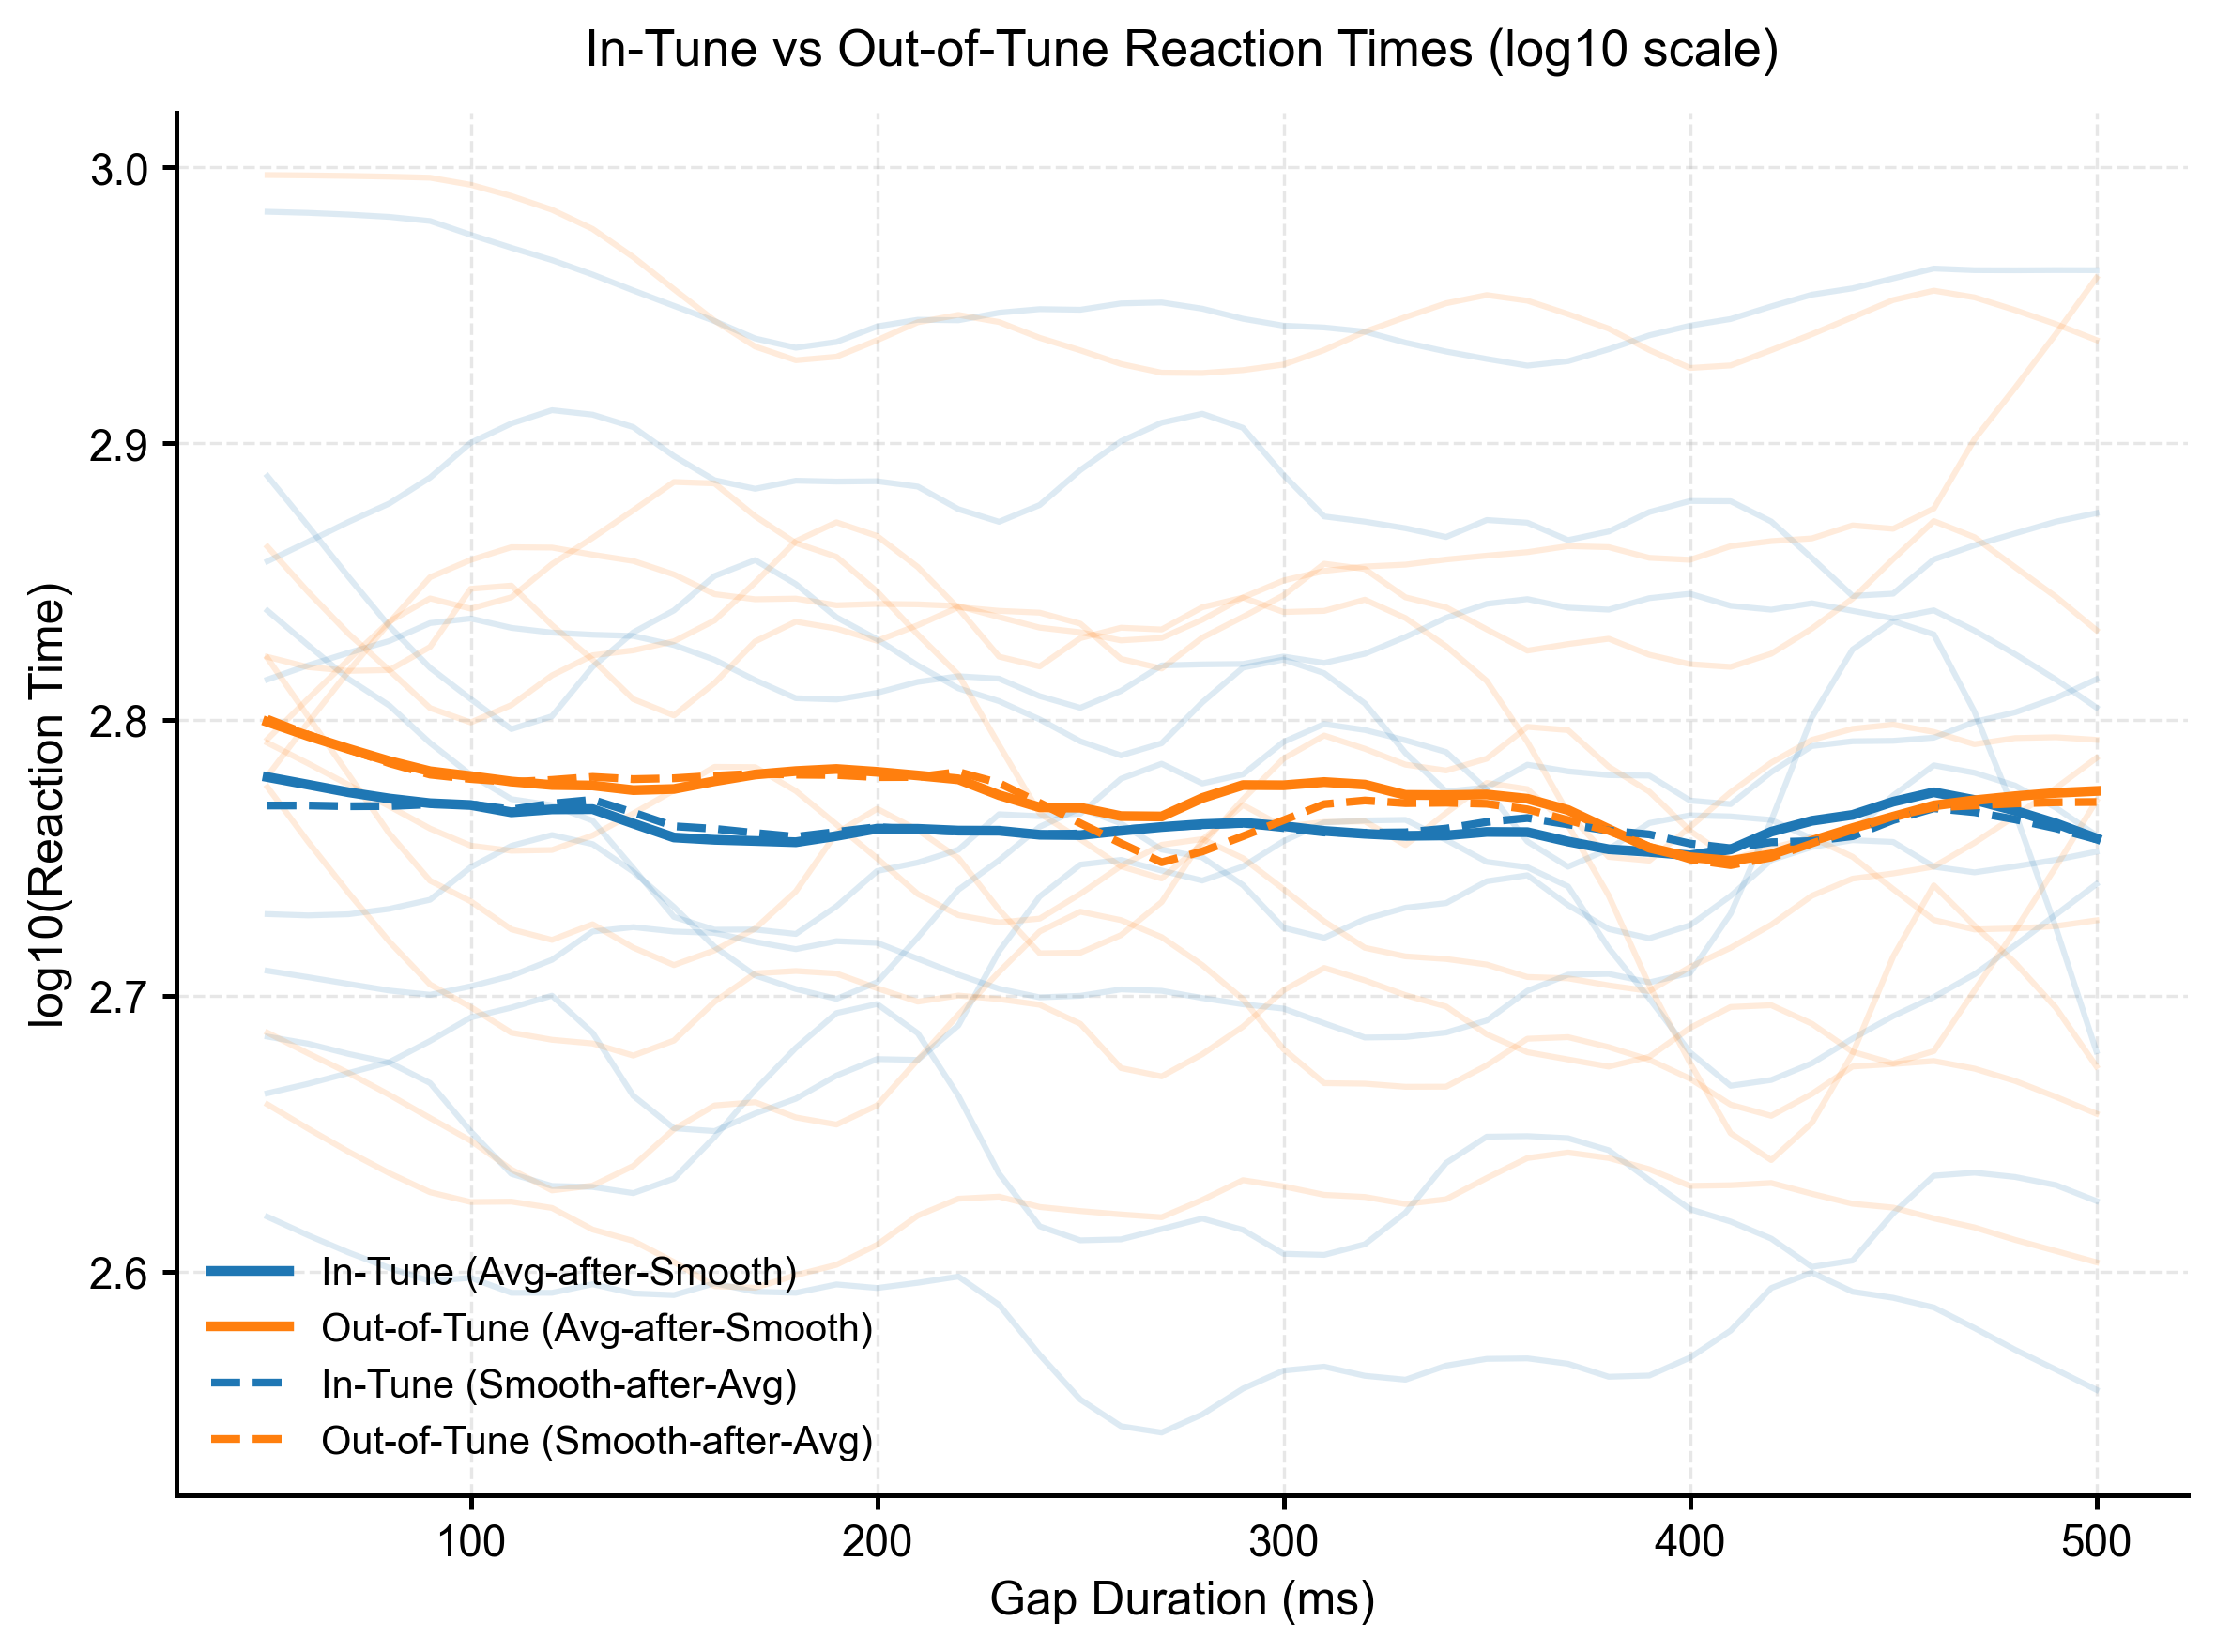


✅ Saved plot to: plots/log_avg_vs_smooth_comparison.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- SETUP ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

# ---- Locate project root ---- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break
else:
    raise FileNotFoundError("❌ Could not find 'Temporal-Attention' directory in path hierarchy.")

base_path = project_root / "data" / "averaged"
print(f"📂 Using base path: {base_path}")

participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

# ---------------- LOAD DATA ---------------- #
in_dfs, out_dfs = [], []

for participant in participants:
    in_path = base_path / participant / f"{participant}_inavg.csv"
    out_path = base_path / participant / f"{participant}_outavg.csv"

    if not in_path.exists() or not out_path.exists():
        print(f"⚠️ Missing data for {participant}, skipping...")
        continue

    in_df = pd.read_csv(in_path)
    out_df = pd.read_csv(out_path)

    in_col = next((c for c in in_df.columns if "InAveRT" in c), None)
    out_col = next((c for c in out_df.columns if "OutAveRT" in c), None)

    if not in_col or not out_col:
        print(f"⚠️ Missing required columns for {participant}, skipping...")
        continue

    # Keep only relevant columns
    in_df = in_df[["Gap", in_col]].rename(columns={in_col: "InRT"})
    out_df = out_df[["Gap", out_col]].rename(columns={out_col: "OutRT"})

    # Merge In/Out per subject
    merged = pd.merge(in_df, out_df, on="Gap", how="inner")

    # Compute per-subject average (raw)
    merged["CombinedRT"] = merged[["InRT", "OutRT"]].mean(axis=1)
    merged["LogInRT"] = np.log10(merged["InRT"])
    merged["LogOutRT"] = np.log10(merged["OutRT"])
    merged["LogCombinedRT"] = np.log10(merged["CombinedRT"])

    in_dfs.append(merged[["Gap", "LogInRT"]].rename(columns={"LogInRT": participant}))
    out_dfs.append(merged[["Gap", "LogOutRT"]].rename(columns={"LogOutRT": participant}))

print(f"✅ Loaded data for {len(in_dfs)} participants.")

# ---------------- HELPER: Merge + Mean ---------------- #
def merge_and_average(dfs):
    merged = dfs[0]
    for df in dfs[1:]:
        merged = pd.merge(merged, df, on="Gap", how="inner")
    subjects = [c for c in merged.columns if c != "Gap"]
    merged["MeanLogRT"] = merged[subjects].mean(axis=1)
    return merged, subjects

# ---------------- STEP 1: Average logs, then smooth ---------------- #
merged_in, subs_in = merge_and_average(in_dfs)
merged_out, subs_out = merge_and_average(out_dfs)

frac = 0.2
smoothed_in_group = lowess(merged_in["MeanLogRT"], merged_in["Gap"], frac=frac)
smoothed_out_group = lowess(merged_out["MeanLogRT"], merged_out["Gap"], frac=frac)

# ---------------- STEP 2: Smooth each subject first, then average ---------------- #
def smooth_each_then_average(dfs, frac=0.2):
    all_gaps = sorted(set(np.concatenate([df['Gap'].values for df in dfs])))
    smoothed_curves = []

    for df in dfs:
        subj = [c for c in df.columns if c != 'Gap'][0]
        smoothed = lowess(df[subj], df['Gap'], frac=frac)
        interp = np.interp(all_gaps, smoothed[:, 0], smoothed[:, 1])
        smoothed_curves.append(interp)

    smoothed_curves = np.vstack(smoothed_curves)
    mean_smoothed = np.mean(smoothed_curves, axis=0)
    return pd.DataFrame({'Gap': all_gaps, 'MeanSmoothedLogRT': mean_smoothed}), smoothed_curves

smoothed_in_df, smoothed_in_curves = smooth_each_then_average(in_dfs, frac=frac)
smoothed_out_df, smoothed_out_curves = smooth_each_then_average(out_dfs, frac=frac)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_in, color_out = plt.get_cmap("tab10")(0), plt.get_cmap("tab10")(1)

# Individual smoothed subject curves (faint)
for curve in smoothed_in_curves:
    ax.plot(smoothed_in_df["Gap"], curve, color=color_in, alpha=0.15)
for curve in smoothed_out_curves:
    ax.plot(smoothed_out_df["Gap"], curve, color=color_out, alpha=0.15)

# Group-averaged smoothed (avg-after-smooth)
ax.plot(smoothed_in_df["Gap"], smoothed_in_df["MeanSmoothedLogRT"], color=color_in, lw=2.5, label="In-Tune (Avg-after-Smooth)")
ax.plot(smoothed_out_df["Gap"], smoothed_out_df["MeanSmoothedLogRT"], color=color_out, lw=2.5, label="Out-of-Tune (Avg-after-Smooth)")

# Group-mean-then-smooth (dashed)
ax.plot(smoothed_in_group[:, 0], smoothed_in_group[:, 1], color=color_in, ls="--", lw=2, label="In-Tune (Smooth-after-Avg)")
ax.plot(smoothed_out_group[:, 0], smoothed_out_group[:, 1], color=color_out, ls="--", lw=2, label="Out-of-Tune (Smooth-after-Avg)")

ax.set_title("In-Tune vs Out-of-Tune Reaction Times (log10 scale)", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("log10(Reaction Time)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "log_avg_vs_smooth_comparison.png"
plt.savefig(save_path, bbox_inches="tight", format="png")
plt.show()

print(f"\n✅ Saved plot to: {save_path.relative_to(project_root)}")